# **_Sample Modeling_** (for Reinforcement Learning with LSTM)

* 이 페이지는 "Drying Oven"의 가상 센서 데이터를 이용하여 PPO 모델을 교육하고 예측하는 예제를 구현합니다. 
* 이 페이지에서는 Liear 대신에 LSTM을 이용하도록 변경합니다.

In [2]:
# ----------------------------------------------------
# Global 변수 선언
# ----------------------------------------------------

csv_file_name = "drying_oven_sensor_v4.csv"
model_path_name = "./recurrent_ppo_dryer_control.pth"
global_num_samples = 1000

### Step 1 가상 센서 데이터 생성

**시나리오**

* 데이터 생성 시나리오
  - 센서 데이터(내부 온도, 습도, 무게, 외부 온도, 팬의 rpm, 압력)와 사용자 조치 데이터(팬의 rpm 절을 위한 행동 데이터, 업/다운)
  - 내부 온도의 목표 온도는 80도 입니다.
  - 초기 가열은 10% 정도이며, 중간에 1차례의 급격한 온도 하강과 1차례의 온도 상승이 있습니다.
  - 사용자 조치 데이터는 센서 데이터를 기반으로 내부 온도가 목표 온도를 유지하도록 하기 위한 조치의 데이터입니다.

* 건조기의 가상 데이터를 생성했습니다. 이 데이터는 목표 온도인 80도를 유지하기 위해 사용자가 팬의 RPM을 조절하는 시나리오를 담고 있습니다.

* 데이터 생성 로직 및 조건 반영
  * 목표 온도: 80도를 기준으로 설정되었습니다.
  * 초기 가열 (0~10%): 25도에서 시작하여 10번째 샘플까지 점진적으로 상승합니다.
  * 급격한 변화:
    * 하강 (40~44 지점): 문 열림 등의 상황을 가정하여 약 25도 급락하며, 사용자는 열 보존을 위해 팬 RPM을 낮춥니다 (DOWN).
    * 상승 (70~74 지점): 히터 과부하 등을 가정하여 약 15도 급등하며, 사용자는 열 배출을 위해 팬 RPM을 높입니다 (UP).
  * 사용자 조치 데이터:
    * inner_temp < 78: 팬 RPM을 낮추는 조치 (DOWN)
    * inner_temp > 82: 팬 RPM을 높이는 조치 (UP)
    * 78 <= inner_temp <= 82: 현재 상태 유지 (KEEP)
  * 기타 센서: 습도는 시간이 지남에 따라 감소(80% → 15%)하고, 무게는 수분 증발로 인해 미세하게 줄어듭니다.

In [3]:
import pandas as pd
import numpy as np

# 1. 설정값 초기화
num_samples = global_num_samples
target_temp = 80
initial_temp = 25

# 시간축 (초 단위 가정)
time = np.arange(num_samples)

# 2. 내부 온도(inner_temp) 생성 로직
inner_temp = np.full(num_samples, target_temp, dtype=float)

# 초기 가열 구간 (0~10%)
heating_end = int(num_samples * 0.1)
inner_temp[:heating_end] = np.linspace(initial_temp, target_temp, heating_end)

# 급격한 온도 하강 시나리오 (40% 지점, 예: 문 열림)
drop_start = int(num_samples * 0.4)
duration = 100 # 변화 지속 시간
inner_temp[drop_start:drop_start+duration] -= np.linspace(0, 30, duration)
# 복구 구간
inner_temp[drop_start+duration:drop_start+duration*2] = np.linspace(inner_temp[drop_start+duration-1], target_temp, duration)

# 급격한 온도 상승 시나리오 (70% 지점, 예: 히터 과열)
spike_start = int(num_samples * 0.7)
inner_temp[spike_start:spike_start+duration] += np.linspace(0, 20, duration)
# 복구 구간
inner_temp[spike_start+duration:spike_start+duration*2] = np.linspace(inner_temp[spike_start+duration-1], target_temp, duration)

# 미세 노이즈 추가 (실제 데이터 느낌 부여)
inner_temp += np.random.normal(0, 0.4, num_samples)

# 3. 기타 센서 데이터 생성
humidity = np.linspace(80, 15, num_samples) + np.random.normal(0, 1, num_samples) # 습도 점진적 감소
weight = np.linspace(5.0, 4.2, num_samples) + np.random.normal(0, 0.01, num_samples) # 무게 감소
outer_temp = np.random.normal(22, 1, num_samples) # 외부 온도 (평균 22도)
pressure = np.random.normal(1013, 2, num_samples) # 대기압

# 4. 사용자 조치 및 팬 RPM 결정 (Down:0, Keep: 1, Up:2)
def determine_action(temp):
    if temp < 78: return "0"   # 온도가 낮으면 팬 속도 감소(열 보존)
    elif temp > 82: return "2" # 온도가 높으면 팬 속도 증가(열 배출)
    else: return "1"           # 적정 온도 유지

actions = [determine_action(t) for t in inner_temp]

# Action에 따른 팬 RPM 수치 할당
fan_rpm = []
for action in actions:
    if action == "0": fan_rpm.append(1200 + np.random.randint(-50, 50))
    elif action == "2": fan_rpm.append(1800 + np.random.randint(-50, 50))
    else: fan_rpm.append(1500 + np.random.randint(-30, 30))

# 5. 데이터프레임 생성 및 확인
df = pd.DataFrame({
    'timestamp': time,
    'inner_temp': np.round(inner_temp, 2),
    'humidity': np.round(humidity, 2),
    'weight': np.round(weight, 3),
    'outer_temp': np.round(outer_temp, 2),
    'pressure': np.round(pressure, 2),
    'fan_rpm': fan_rpm,
    'user_action': actions
})

# 결과 출력 (상위 10개 및 하강 구간 확인)
print("--- 초기 가열 구간 데이터 ---")
print(df.head(10))
print("\n--- 온도 하강 발생 구간 데이터 (4000번 인덱스 부근) ---")
print(df.iloc[4000:4010])

# CSV 파일로 저장
df.to_csv(csv_file_name, index=False)

--- 초기 가열 구간 데이터 ---
   timestamp  inner_temp  humidity  weight  outer_temp  pressure  fan_rpm  \
0          0       24.86     79.91   4.999       22.27   1009.70     1236   
1          1       25.26     80.82   4.981       21.66   1013.55     1189   
2          2       25.88     81.69   5.005       22.92   1013.38     1161   
3          3       27.21     80.64   5.004       21.50   1012.55     1207   
4          4       27.27     79.62   4.997       22.68   1011.68     1169   
5          5       27.85     81.89   4.981       22.21   1012.18     1161   
6          6       28.19     79.39   4.998       22.78   1009.56     1162   
7          7       28.51     79.42   4.980       22.16   1009.84     1153   
8          8       29.11     80.30   4.990       22.69   1014.28     1184   
9          9       29.97     80.51   4.987       21.78   1010.40     1206   

  user_action  
0           0  
1           0  
2           0  
3           0  
4           0  
5           0  
6           0  
7  

### Step 2 Env 생성

##### 2.1 보상 함수 (풍압 중심 제어)

**_주요 구성 요소 설명_**

* Observation Space: 이전 가상 데이터의 모든 컬럼을 포함합니다. RecurrentPPO는 내부적으로 이 데이터의 변화 추이를 학습합니다.
* 물리 시뮬레이션: step 함수 내에서 RPM 수치에 따라 온도가 변하도록 설계했습니다. 특히 요청하신 40% 지점 하강, 70% 지점 상승 시나리오를 강제로 발생시켜 모델이 이를 극복하도록 유도합니다.
* Reward Function: 단순히 80도에 가깝게 유지하는 것뿐만 아니라, 범위를 벗어날 경우 패널티를 주어 모델이 "사용자 조치(UP/DOWN)"를 적극적으로 학습하게 합니다.
* RecurrentPPO 활용 팁: Stable-Baselines3-Contrib 라이브러리의 RecurrentPPO를 사용하신다면, policy="MlpLstmPolicy"를 설정하여 이 환경을 바로 학습시킬 수 있습니다.

In [18]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class DryerEnv(gym.Env):
    """
    RecurrentPPO 학습을 위한 건조기 온도 제어 환경
    목표: 팬 RPM을 조절하여 내부 온도를 80도로 유지하기
    """
    # def __init__(self, send_fn, read_fn, target_temp=80.0, env_simulation=True, debug=False):
    #     super(DryingOvenEnv, self).__init__()
    init_sim_data = [{
            "inner_temp": 79.5,  # 실측 온도
            "humidity": 45.2,    # 실측 습도
            "weight": 4.65,      # 실측 무게
            "outer_temp": 22.1,
            "pressure": 1012.8,
            "fan_rpm": 1550.0,
            "user_action": 0
        },
        {
            "inner_temp": 25,  # 실측 온도
            "humidity": 80,    # 실측 습도
            "weight": 5.0,      # 실측 무게
            "outer_temp": 22.0,
            "pressure": 1013.0,
            "fan_rpm": 1500.0,
            "user_action": 2
        }
    ]

    def __init__(self, is_simulatation=True):
        super(DryerEnv, self).__init__()

        # 1. Action Space: [0: DOWN, 1: KEEP, 2: UP]
        self.action_space = spaces.Discrete(3)

        # 2. Observation Space: [내부온도, 습도, 무게, 외부온도, 압력, 현재RPM]
        # RecurrentPPO는 이 벡터의 시퀀스를 입력으로 받음
        self.observation_space = spaces.Box(
            low=np.array([0, 0, 0, 0, 900, 1000, 0]), 
            high=np.array([150, 100, 10, 50, 1100, 2500, 2]), 
            dtype=np.float32
        )
        self.is_simulation = is_simulatation

        self.target_temp = 80.0
        self.max_steps = 10000
        self.state = np.array([])
        self.terminated = False
        self.reset()
    
    def _generate_simul_data(self, state, pre_user_action):
        inner_temp, humidity, weight, outer_temp, pressure, fan_rpm = state

        # 1. Action 적용 (RPM 조절)
        if pre_user_action == 0:   # DOWN
            fan_rpm -= 50
        elif pre_user_action == 2: # UP
            fan_rpm += 50
        # action 1 (KEEP)은 유지
        fan_rpm = np.clip(fan_rpm, 1000, 2500)

        operator_fn = None # 1. 초기값 설정
        if pre_user_action == '2':
            operator_fn = lambda x, y: x - y
        elif pre_user_action == '0':
            operator_fn = lambda x, y: x + y

        # 2. 물리 엔진 시뮬레이션 (데이터 생성 로직 반영)
        # 기본 가열 (RPM이 낮을수록 온도가 더 잘 오름 - 밀폐 가정)
        heat_gain = 0.5 * (2000 / fan_rpm)
        if operator_fn is not None:
            inner_temp = operator_fn(inner_temp, heat_gain)

        # 습도 및 무게 자연 감소
        humidity = max(15.0, humidity - 0.01)
        weight = max(4.2, weight - 0.0001)

        return {
                "inner_temp": inner_temp,
                "humidity": humidity,
                "weight": weight,
                "outer_temp": outer_temp,
                "pressure": pressure,
                "fan_rpm": fan_rpm}

    def _send_action_to_dryer(self, action):
        """
        건조기 하드웨어로 제어 신호(RPM 조절)를 전송하는 함수
        실제 환경에서는 MQTT publish나 API POST 요청이 들어갑니다.
        """
        action_map = {0: "DOWN", 1: "KEEP", 2: "UP"}
        command = action_map[action]
        
        # 예시: requests.post(f"http://dryer-ip/control", json={"action": command})
        # print(f"[Hardware] Sent command: {command} to {self.device_id}")
        pass

    def _get_data_from_dryer(self, pre_user_action):
        """
        건조기 센서로부터 실측 데이터를 읽어오는 함수
        실제 환경에서는 센서 API 호출이나 DB 조회가 들어갑니다.
        """
        # 예시: response = requests.get(f"http://dryer-ip/sensors").json()
        # 가상의 실측 데이터 구조 (API 응답 가정)
        if self.is_simulation:
            if len(self.state) == 0:
                real_measured_data = DryerEnv.init_sim_data[1]
            else:
                real_measured_data = self._generate_simul_data(self.state, pre_user_action)
        else:
            ## 실제 상황에서는 건조기에서 데이터를 가져와야 합니다. 
            real_measured_data = DryerEnv.init_sim_data[0]
            
        return np.array([real_measured_data["inner_temp"],
                         real_measured_data["humidity"],
                         real_measured_data["weight"],
                         real_measured_data["outer_temp"],
                         real_measured_data["pressure"],
                         real_measured_data["fan_rpm"]],
                         dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        
        self.current_step = 0
        if self.terminated:
            pre_user_action = 0
        else:
            pre_user_action = 1
        self.state = self._get_data_from_dryer(pre_user_action=pre_user_action)
        self.terminated = False
        return self.state, {}

    def _generate_reward(self):
        """
        # 보상(Reward)
        ; params none
        ; return reward, terminated, truncated
        """
        inner_temp, _, _, _, _, _ = self.state

        # 목표 온도(80도)와의 차이에 대한 패널티
        temp_diff = abs(inner_temp - self.target_temp)
        reward = -temp_diff 
        
        # 목표 온도 근처(±2도)에 도달 시 추가 보상
        if temp_diff < 2.0:
            reward += 10.0

        # 4. 종료 조건
        terminated = self.current_step >= self.max_steps
        truncated = False
        # 온도가 너무 높거나 낮아지면 에피소드 조기 종료 (Safety)
        if inner_temp > 90 or inner_temp < 15:
            terminated = True
            reward -= 100
        return reward, terminated, truncated

    def step(self, action):
        self.current_step += 1
        self._send_action_to_dryer(action)
        self.state = self._get_data_from_dryer(pre_user_action=action)
        reward, terminated, truncated = self._generate_reward()
        self.terminated = terminated
        return self.state, reward, terminated, truncated, {}

# 환경 테스트
if __name__ == "__main__":
    env = DryerEnv()
    obs, _ = env.reset()
    print(f"Initial Obs: {obs}")
    
    # 랜덤 액션 테스트
    for _ in range(5):
        action = env.action_space.sample()
        obs, reward, done, _, _ = env.step(action)
        print(f"Action: {action}, Temp: {obs[0]:.2f}, Reward: {reward:.2f}")


Initial Obs: [  25.       79.99      4.9999   22.     1013.     1500.    ]
Action: 0, Temp: 25.00, Reward: -55.00
Action: 2, Temp: 25.00, Reward: -55.00
Action: 0, Temp: 25.00, Reward: -55.00
Action: 2, Temp: 25.00, Reward: -55.00
Action: 2, Temp: 25.00, Reward: -55.00


### Step 3 모방 학습(Behavioral Cloning)으로 PPO 초기화하기

##### Step 3.1 가상 데이터를 Transitions 데이터로 변환

In [5]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

df = pd.read_csv(csv_file_name)
obs = df[['inner_temp', 'humidity', 'weight', 'outer_temp', 'pressure', 'fan_rpm', 'user_action']]
acts = df[['user_action']]
obs = torch.tensor(obs.values, dtype=torch.float32)
acts = torch.tensor(acts.values, dtype=torch.float32)
dataset = TensorDataset(obs, acts)
loader = DataLoader(dataset, batch_size=64, shuffle=True)
# loader = DataLoader(dataset, batch_size=32, shuffle=True)
print(f'obs\'s len = {len(obs)}')


# df = pd.DataFrame(data, columns=['internal_temp', 'humidity', 'weight', 'surface_temp', 'fan_rpm', 'air_pressure', 'heater_state'])


obs's len = 1000


##### 3.2 Trasitions 데이터로 모방 학습 하기

* pytorch를 이용
* 가상 데이터 준비 및 BC 학습 (Pre-training)
* 가상 데이터에서 (State) -> (Action) 관계를 지도 학습(Supervised Learning)으로 먼저 익힙니다.

In [8]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np

class CSVDataDryerEnv(DryerEnv):
    def __init__(self, csv_file='dryer_virtual_data.csv'):
        # 데이터 로드
        self.df = pd.read_csv(csv_file)
        self.max_steps = len(self.df) - 1

        super(CSVDataDryerEnv, self).__init__()        
        # Action & Observation Space
        # self.action_space = spaces.Discrete(3)
        # obs: [inner_temp, humidity, weight, outer_temp, pressure, fan_rpm]
        # self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)
        
        # self.target_temp = 80.0
        # self.current_step = 0

    def _get_obs_from_df(self, step):
        # CSV의 특정 행에서 데이터를 가져와서 state로 반환
        row = self.df.iloc[step]
        return np.array([
            row['inner_temp'],
            row['humidity'],
            row['weight'],
            row['outer_temp'],
            row['pressure'],
            row['fan_rpm'],
            row['user_action']
        ], dtype=np.float32)

    def reset(self, seed=None, options=None):
        print(f'CSVDataDryerEnv.reset.#1')
        super().reset(seed=seed)
        self.current_step = 0
        self.state = self._get_obs_from_df(self.current_step)
        return self.state, {}

    def step(self, action):
        print(f'CSVDataDryerEnv.step.#1')
        # 1. 이전 단계에서 조치값(action)을 보냈다고 가정 (로그 기록용 등)
        # 실제 CSV 학습에서는 데이터에 기록된 'user_action'과 비교하여 보상을 줄 수도 있습니다.
        
        # 2. 다음 타임스텝의 실측 데이터를 CSV에서 가져옴
        self.current_step += 1
        if self.current_step > self.max_steps:
            self.current_step = self.max_steps # 인덱스 초과 방지
        
        self.state = self._get_obs_from_df(self.current_step)
        
        reward, terminated, truncated = self._generate_reward()
        self.terminated = terminated
        print(f'CSVDataDryerEnv.step.#2 state={self.state}, action={action},reward={reward},terminated={terminated}')
        return self.state, reward, terminated, truncated, {}

In [ ]:
import gymnasium as gym
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import CheckpointCallback

# 앞에서 정의한 DryerEnv 클래스가 같은 파일에 있거나 import 되었다고 가정합니다.
# from your_env_file import DryerEnv 

def train_dryer_model_from_csv(model_path_name: str,csv_path: str='dryer_virtual_data.csv', learn_repeat_cnt: int=5):
    # 1. CSV 기반 환경 생성
    env = CSVDataDryerEnv(csv_file=csv_path)

    # 2. 모델 설정 (LSTM 기반 RecurrentPPO)
    model = RecurrentPPO(
        "MlpLstmPolicy",
        env,
        verbose=1,
        n_steps=128,
        batch_size=64,
        learning_rate=1e-4
    )

    # 3. 학습 시작
    # CSV 데이터의 크기에 맞춰 학습 횟수를 조절하세요.
    print(f"{csv_path} 데이터를 기반으로 학습을 시작합니다...")
    model.learn(total_timesteps=len(env.df) * learn_repeat_cnt) # 데이터를 5번 반복 학습

    # 4. 저장
    model.save(model_path_name)
    print("학습 및 모델 저장 완료")
    
    return model

if __name__ == "__main__":
    # 학습 실행
    # checkpoint_callback = CheckpointCallback(save_freq=5000, save_path='./logs/', name_prefix='dryer_model')
    # trained_model = train_dryer_model(model_path_name=model_path_name, total_timesteps=10000, n_epochs=1)
    train_dryer_model_from_csv(model_path_name=model_path_name, csv_path=csv_file_name, learn_repeat_cnt=1)



**_학습 포인트 (Tips for Success)_**

- LSTM 상태 관리: model.predict를 할 때 state와 episode_start 인자를 넘겨주는 것이 핵심입니다. 이를 통해 모델이 이전 시점의 온도 변화(급격한 하강/상승)를 기억하고 대응하게 됩니다.
- 보상(Reward) 튜닝: 만약 모델이 온도를 잘 못 맞춘다면, DryerEnv의 reward = -temp_diff 부분을 reward = -(temp_diff**2) 처럼 제곱으로 바꾸어 오차에 더 민감하게 만들 수 있습니다.
- 데이터 정규화: 실제 환경에서는 온도(25~100)와 무게(4~5)의 수치 범위가 매우 다릅니다. 학습 효율을 높이려면 Stable-Baselines3의 VecNormalize 래퍼를 사용하여 관측치를 0~1 사이로 정규화하는 것을 추천합니다.

### 4. Test

Step 0: Temp=26.36, Action=0, Reward=-53.64
Step 10: Temp=34.94, Action=0, Reward=-45.06
Step 20: Temp=44.94, Action=0, Reward=-35.06
Step 30: Temp=54.94, Action=0, Reward=-25.06
Step 40: Temp=64.94, Action=0, Reward=-15.06
Step 50: Temp=74.94, Action=0, Reward=-5.06
Step 60: Temp=84.94, Action=0, Reward=-4.94


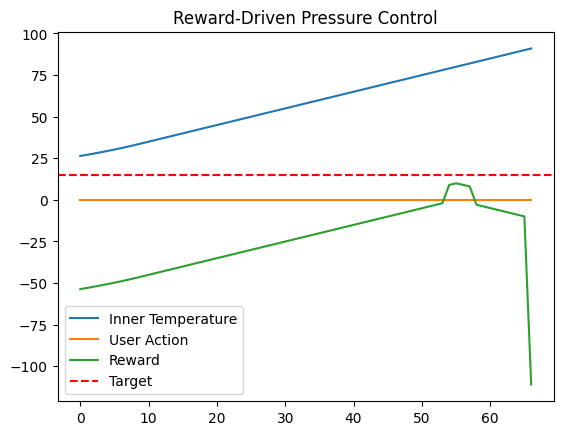

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

innert_temp_history = []
action_history = []
reward_history = []
repeat_cnt = 100

def test_model(model_path_name="recurrent_ppo_dryer_control", repeat_cnt=100):
    # 저장된 모델 로드 및 테스트
    env = DryerEnv()
    model = RecurrentPPO.load(model_path_name)
    model.env = env

    obs, _ = env.reset()
    # LSTM 상태 초기화 (Recurrent 모델은 상태 관리가 필요함)
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)

    for i in range(repeat_cnt):
        # 모델 예측 (deterministic=True: 가장 확률 높은 액션 선택)
        action, lstm_states = model.predict(
            obs, 
            state=lstm_states, 
            episode_start=episode_starts, 
            deterministic=True
        )

        action = int(action)
        obs, reward, terminated, truncated, _ = env.step(action)
        if i % 10 == 0:
            print( f"Step {i}: Temp={obs[0]:.2f}, Action={action}, Reward={reward:.2f}")
        innert_temp_history.append(obs[0])
        action_history.append(action)
        reward_history.append(reward)
        
        if terminated or truncated:
            break

test_model(model_path_name=model_path_name, repeat_cnt=10000)

plt.plot(innert_temp_history, label='Inner Temperature')
plt.plot(action_history, label='User Action')
plt.plot(reward_history, label='Reward')
plt.axhline(15, color='r', linestyle='--', label='Target')
plt.title("Reward-Driven Pressure Control")
plt.legend()
plt.show()
# plt.plot(press_history, label='Air Pressure (Pa)')
# plt.axhline(15, color='r', linestyle='--', label='Target')
# plt.title("Reward-Driven Pressure Control")
# plt.legend()
# plt.show()